In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from keras.applications.densenet import DenseNet169, DenseNet121
from keras.applications.mobilenet import MobileNet
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import classification_report
import lightgbm as lgb
import seaborn as sns

In [2]:
SIZE = 224
images = []
images_labels = [] 

In [3]:
ext = ['jpeg'] 

for directory_path in glob.glob("D:/new/*"):
    splited = directory_path.split("/")
    label = splited[-1]
    print(label)
    for e in ext:
      for img_path in glob.glob(os.path.join(directory_path, "*." + e)):
           print(img_path)
           img = cv2.imread(img_path, cv2.IMREAD_COLOR)       
           img = cv2.resize(img, (SIZE, SIZE))
           images.append(img)
           images_labels.append(label)

new\Normal
D:/new\Normal\IM-0001-0001.jpeg
D:/new\Normal\IM-0003-0001.jpeg
D:/new\Normal\IM-0005-0001.jpeg
D:/new\Normal\IM-0006-0001.jpeg
D:/new\Normal\IM-0007-0001.jpeg
D:/new\Normal\IM-0009-0001.jpeg
D:/new\Normal\IM-0010-0001.jpeg
D:/new\Normal\IM-0011-0001-0001.jpeg
D:/new\Normal\IM-0011-0001-0002.jpeg
D:/new\Normal\IM-0011-0001.jpeg
D:/new\Normal\IM-0013-0001.jpeg
D:/new\Normal\IM-0015-0001.jpeg
D:/new\Normal\IM-0016-0001.jpeg
D:/new\Normal\IM-0017-0001.jpeg
D:/new\Normal\IM-0019-0001.jpeg
D:/new\Normal\IM-0021-0001.jpeg
D:/new\Normal\IM-0022-0001.jpeg
D:/new\Normal\IM-0023-0001.jpeg
D:/new\Normal\IM-0025-0001.jpeg
D:/new\Normal\IM-0027-0001.jpeg
D:/new\Normal\IM-0028-0001.jpeg
D:/new\Normal\IM-0029-0001.jpeg
D:/new\Normal\IM-0030-0001.jpeg
D:/new\Normal\IM-0031-0001.jpeg
D:/new\Normal\IM-0033-0001-0001.jpeg
D:/new\Normal\IM-0033-0001-0002.jpeg
D:/new\Normal\IM-0033-0001.jpeg
D:/new\Normal\IM-0035-0001.jpeg
D:/new\Normal\IM-0036-0001.jpeg
D:/new\Normal\IM-0037-0001.jpeg
D:/new\No

In [4]:
images = np.array(images)
images_labels = np.array(images_labels)

In [5]:
images.shape

(5856, 224, 224, 3)

In [6]:
np.unique(images_labels)

array(['new\\Normal', 'new\\Pneumonia'], dtype='<U13')

In [7]:
le = preprocessing.LabelEncoder()
le.fit(images_labels)
labels_encoded = le.transform(images_labels)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(images, labels_encoded, test_size=0.2, random_state=0)

In [9]:
dense_model = DenseNet169(include_top=False, input_shape=(SIZE, SIZE, 3), pooling='avg')

In [10]:
dense_features = dense_model.predict(x_train)

In [11]:
features1 = dense_features.reshape(dense_features.shape[0], -1)

In [12]:
features1.shape

(4684, 1664)

In [13]:
model_mobile = MobileNet(weights='imagenet',include_top=False, input_shape=(SIZE, SIZE, 3), pooling='avg')

In [14]:
mobile_features = model_mobile.predict(x_train)     

In [15]:
features2 = mobile_features.reshape(mobile_features.shape[0], -1)

In [16]:
features2.shape

(4684, 1024)

In [17]:
params = {'learning_rate':0.24, 'n_iterations': 250, 'max_depth': 7, 'num_leaves': 105, 'n_estimators': 300, 'min_child_samples': 40}

In [18]:
lgb_classifier = lgb.LGBMClassifier(**params)

In [19]:
lgb_classifier.fit(dense_features, y_train)

[LightGBM] [Warning] Unknown parameter: n_iterations


LGBMClassifier(learning_rate=0.24, max_depth=7, min_child_samples=40,
               n_estimators=300, n_iterations=250, num_leaves=105)

In [20]:
X_test_dense_features = dense_model.predict(x_test)
X_test_dense_features = X_test_dense_features.reshape(X_test_dense_features.shape[0], -1)

In [21]:
X_test_mobile_features = model_mobile.predict(x_test)
X_test_mobile_features = X_test_mobile_features.reshape(X_test_mobile_features.shape[0], -1)

In [22]:
prediction1 = lgb_classifier.predict(X_test_dense_features)

In [23]:
accuracy1 = accuracy_score(y_test, prediction1)
accuracy1

0.9607508532423208

In [24]:
cm = confusion_matrix(y_test, prediction1)

In [25]:
def confusion_metrics(cm, class_name):
  report = classification_report(y_test, prediction1, target_names=categories, output_dict=True)


  if class_name == 'normal':
      sensitivity = cm[1,1]/sum(cm[1,:])
      specificity = cm[0,0]/sum(cm[0,:])
      precision = report[class_name]['precision']
      f1 = report[class_name]['f1-score']

  elif class_name == 'pneumonia':
      sensitivity = cm[0,0]/sum(cm[0,:])
      specificity = cm[1,1]/sum(cm[1,:])
      precision = report[class_name]['precision']
      f1 = report[class_name]['f1-score']
 
  result = {'Sensitivity': sensitivity*100, 'Specificity': specificity *
              100, 'Precision': precision*100, 'F1-Score': f1*100}
  return result
     

In [26]:
performance = pd.DataFrame(
    columns=['Class', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'Accuracy'])
performance

,Class,Sensitivity,Specificity,Precision,F1-Score,Accuracy


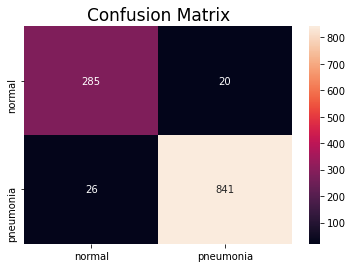

In [27]:
from sklearn.metrics import confusion_matrix
#compute the confusion matrix.
cm = confusion_matrix(y_test,prediction1)
 
#Plot the confusion matrix.
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['normal','pneumonia'],
            yticklabels=['normal','pneumonia'])
#plt.ylabel('Prediction',fontsize=13)
#plt.xlabel('y_test',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

In [28]:
import numpy as np

conf_matrix = np.array([[285, 20], [26, 841]])

def calculate_metrics(confusion_matrix):
    true_positives = confusion_matrix[1, 1]
    true_negatives = confusion_matrix[0, 0]
    false_positives = confusion_matrix[0, 1]
    false_negatives = confusion_matrix[1, 0]

    # Accuracy
    accuracy = (true_positives + true_negatives) / np.sum(confusion_matrix)

    # Precision
    precision = true_positives / (true_positives + false_positives)

    # Sensitivity (Recall)
    sensitivity = true_positives / (true_positives + false_negatives)

    # Specificity
    specificity = true_negatives / (true_negatives + false_positives)

    # F1 Score
    f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1_score
    }

# Calculate metrics
metrics = calculate_metrics(conf_matrix)

# Print the results
for metric, value in metrics.items():
    print(f"{metric}: {value}")

Accuracy: 0.9607508532423208
Precision: 0.9767711962833914
Sensitivity: 0.9700115340253749
Specificity: 0.9344262295081968
F1 Score: 0.9733796296296297


In [29]:
lgb_classifier.fit(mobile_features, y_train)

[LightGBM] [Warning] Unknown parameter: n_iterations


LGBMClassifier(learning_rate=0.24, max_depth=7, min_child_samples=40,
               n_estimators=300, n_iterations=250, num_leaves=105)

In [30]:
prediction2 = lgb_classifier.predict(X_test_mobile_features)

In [31]:
accuracy2 = accuracy_score(y_test, prediction2)
accuracy2

0.947098976109215

In [32]:
cm = confusion_matrix(y_test, prediction2)

In [33]:
def confusion_metrics(cm, class_name):
  report = classification_report(y_test, prediction2, target_names=categories, output_dict=True)


  if class_name == 'normal':
      sensitivity = cm[1,1]/sum(cm[1,:])
      specificity = cm[0,0]/sum(cm[0,:])
      precision = report[class_name]['precision']
      f1 = report[class_name]['f1-score']

  elif class_name == 'pneumonia':
      sensitivity = cm[0,0]/sum(cm[0,:])
      specificity = cm[1,1]/sum(cm[1,:])
      precision = report[class_name]['precision']
      f1 = report[class_name]['f1-score']
 
  result = {'Sensitivity': sensitivity*100, 'Specificity': specificity *
              100, 'Precision': precision*100, 'F1-Score': f1*100}
  return result

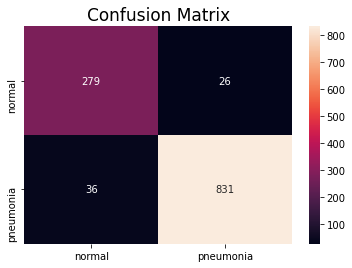

In [34]:
from sklearn.metrics import confusion_matrix
#compute the confusion matrix.
cm = confusion_matrix(y_test,prediction2)
 
#Plot the confusion matrix.
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['normal','pneumonia'],
            yticklabels=['normal','pneumonia'])
#plt.ylabel('Prediction',fontsize=13)
#plt.xlabel('y_test',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

In [35]:
import numpy as np

conf_matrix = np.array([[279, 26], [36, 831]])

def calculate_metrics(confusion_matrix):
    true_positives = confusion_matrix[1, 1]
    true_negatives = confusion_matrix[0, 0]
    false_positives = confusion_matrix[0, 1]
    false_negatives = confusion_matrix[1, 0]

    # Accuracy
    accuracy = (true_positives + true_negatives) / np.sum(confusion_matrix)

    # Precision
    precision = true_positives / (true_positives + false_positives)

    # Sensitivity (Recall)
    sensitivity = true_positives / (true_positives + false_negatives)

    # Specificity
    specificity = true_negatives / (true_negatives + false_positives)

    # F1 Score
    f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1_score
    }

# Calculate metrics
metrics = calculate_metrics(conf_matrix)

# Print the results
for metric, value in metrics.items():
    print(f"{metric}: {value}")

Accuracy: 0.947098976109215
Precision: 0.969661610268378
Sensitivity: 0.9584775086505191
Specificity: 0.9147540983606557
F1 Score: 0.9640371229698376


In [36]:
from tensorflow.keras.applications import EfficientNetB0

In [37]:
eff_base_model = EfficientNetB0(weights='imagenet', include_top=True)

In [38]:
efficientnet_features = eff_base_model.predict(x_train)     

In [39]:
features3 = efficientnet_features.reshape(efficientnet_features.shape[0], -1)

In [40]:
features3.shape

(4684, 1000)

In [41]:
lgb_classifier.fit(efficientnet_features, y_train)

[LightGBM] [Warning] Unknown parameter: n_iterations


LGBMClassifier(learning_rate=0.24, max_depth=7, min_child_samples=40,
               n_estimators=300, n_iterations=250, num_leaves=105)

In [42]:
X_test_efficientnet_features = eff_base_model.predict(x_test)
X_test_efficientnet_features = X_test_efficientnet_features.reshape(X_test_dense_features.shape[0], -1)

In [43]:
prediction3 = lgb_classifier.predict(X_test_efficientnet_features)

In [44]:
accuracy3 = accuracy_score(y_test, prediction3)
accuracy3

0.96160409556314

In [45]:
cm = confusion_matrix(y_test, prediction3)

In [46]:
def confusion_metrics(cm, class_name):
  report = classification_report(y_test, prediction3, target_names=categories, output_dict=True)


  if class_name == 'normal':
      sensitivity = cm[1,1]/sum(cm[1,:])
      specificity = cm[0,0]/sum(cm[0,:])
      precision = report[class_name]['precision']
      f1 = report[class_name]['f1-score']

  elif class_name == 'pneumonia':
      sensitivity = cm[0,0]/sum(cm[0,:])
      specificity = cm[1,1]/sum(cm[1,:])
      precision = report[class_name]['precision']
      f1 = report[class_name]['f1-score']
 
  result = {'Sensitivity': sensitivity*100, 'Specificity': specificity *
              100, 'Precision': precision*100, 'F1-Score': f1*100}
  return result

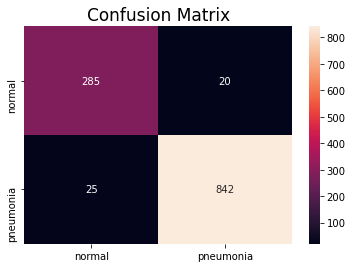

In [47]:
from sklearn.metrics import confusion_matrix
#compute the confusion matrix.
cm = confusion_matrix(y_test,prediction3)
 
#Plot the confusion matrix.
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['normal','pneumonia'],
            yticklabels=['normal','pneumonia'])
#plt.ylabel('Prediction',fontsize=13)
#plt.xlabel('y_test',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

In [48]:
import numpy as np

conf_matrix = np.array([[285, 20], [25, 842]])

def calculate_metrics(confusion_matrix):
    true_positives = confusion_matrix[1, 1]
    true_negatives = confusion_matrix[0, 0]
    false_positives = confusion_matrix[0, 1]
    false_negatives = confusion_matrix[1, 0]

    # Accuracy
    accuracy = (true_positives + true_negatives) / np.sum(confusion_matrix)

    # Precision
    precision = true_positives / (true_positives + false_positives)

    # Sensitivity (Recall)
    sensitivity = true_positives / (true_positives + false_negatives)

    # Specificity
    specificity = true_negatives / (true_negatives + false_positives)

    # F1 Score
    f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1_score
    }

# Calculate metrics
metrics = calculate_metrics(conf_matrix)

# Print the results
for metric, value in metrics.items():
    print(f"{metric}: {value}")

Accuracy: 0.96160409556314
Precision: 0.9767981438515081
Sensitivity: 0.9711649365628604
Specificity: 0.9344262295081968
F1 Score: 0.9739733950260265


(4684, 25088)

In [100]:
import numpy as np

conf_matrix = np.array([[285, 20], [25, 842]])

def calculate_metrics(confusion_matrix):
    true_positives = confusion_matrix[1, 1]
    true_negatives = confusion_matrix[0, 0]
    false_positives = confusion_matrix[0, 1]
    false_negatives = confusion_matrix[1, 0]

    # Accuracy
    accuracy = (true_positives + true_negatives) / np.sum(confusion_matrix)

    # Precision
    precision = true_positives / (true_positives + false_positives)

    # Sensitivity (Recall)
    sensitivity = true_positives / (true_positives + false_negatives)

    # Specificity
    specificity = true_negatives / (true_negatives + false_positives)

    # F1 Score
    f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1_score
    }

# Calculate metrics
metrics = calculate_metrics(conf_matrix)

# Print the results
for metric, value in metrics.items():
    print(f"{metric}: {value}")

Accuracy: 0.96160409556314
Precision: 0.9767981438515081
Sensitivity: 0.9711649365628604
Specificity: 0.9344262295081968
F1 Score: 0.9739733950260265
